In [2]:
#imports

import json
import matplotlib.pyplot as plt
import os
from Point import Point
from SkeletonEdge import SkeletonEdge

In [5]:
keypoints_labels = [
    "head", "nose", "neck", "rightShoulder", "rightElbow", "rightWrist",
    "leftShoulder", "leftElbow", "leftWrist", "rightHip", "rightKnee", "rightAnkle",
    "leftHip", "leftKnee", "leftAnkle", "rightFoot", "leftFoot"
]
IMG_WIDTH = 640
IMG_HEIGHT = 480
skeleton_links = [
    (0, 1), (0, 2), (2, 3), (3, 4), (4, 5),
    (2, 6), (6, 7), (7, 8),
    (2, 9), (9, 10), (10, 11), (11, 15),
    (2, 12), (12, 13), (13, 14), (14, 16)
]

pose = "cam6_vid2_seg8"
with open(f"W:\\staff-bulk\\ewi\\insy\\SPCDataSets\\conflab-mm\\v4\\release\\annotations\\pose\\coco\\cam2_vid2_seg8_coco.json") as f:
    data = json.load(f)
OUTPUT_DIR = f"poseEstimations\\{pose}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

skeleton_frames = data["annotations"]["skeletons"]


KeyboardInterrupt: 

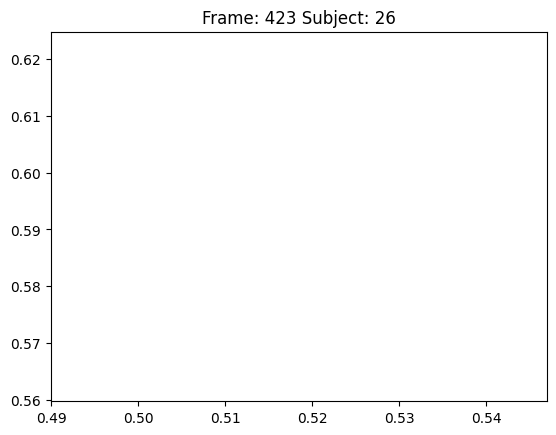

In [6]:
for frame_id, frame_data in enumerate(skeleton_frames):

    person_points = dict()
    for pid, pdata in frame_data.items():
        points = Point.populate(pdata["keypoints"], keypoints_labels)
        plt.title(f"Frame: {frame_id} Subject: {pid}")

        for i, j in skeleton_links:
            edge = SkeletonEdge(points[i], points[j])
            if edge.isNone(): continue
            plt.plot([edge.p1.x, edge.p2.x], [edge.p1.y, edge.p2.y], color=edge.color)
        subject_dir = os.path.join(OUTPUT_DIR, f"s{pid}")
        os.makedirs(subject_dir, exist_ok=True)
        filename = os.path.join(subject_dir, f"Frame_{frame_id}_Subject_{pid}")
        plt.savefig(filename)
        plt.close()


In [ ]:
# Assigning subjects to the most visible camera




